# BatteryPlotter 使用示例

演示 `src.plotting.BatteryPlotter` 在**不依赖 PyBaMM 仿真**情况下的核心用法：
如何注入数据、绘制实验/仿真对比图、按关键词筛选、共享颜色。

需要 `sol_list` 的 `plot_swelling` / `plot_heat` 见 [analysis_demo.ipynb](analysis_demo.ipynb)
与 [compare_demo.ipynb](compare_demo.ipynb)。

In [ ]:
# --- BatteryProject 路径自动定位 (无论从 root 还是 examples/ 启动 notebook 都能工作) ---
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
for _cand in (_HERE, *_HERE.parents):
    if (_cand / "src" / "easy_imports.py").exists() and (_cand / "pyproject.toml").exists():
        _ROOT = _cand
        break
else:
    raise RuntimeError(f"Cannot locate BatteryProject root from {_HERE}")
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("BatteryProject root:", _ROOT)

In [ ]:
# 用 easy_imports 一次性拿到 BatteryPlotter、配置常量、matplotlib 默认风格
from src.easy_imports import *
import numpy as np
import matplotlib.pyplot as plt

## 1. 最小用例：实验 + 仿真 容量/保持率对比

`BatteryPlotter` 是一个状态机：先用 `add_exp_data` / `add_sim_data` 注入若干组数据，
再调用 `plot()` 渲染。注意默认 `target_exp=None, target_sim=None` 会**画不出任何线**——
必须显式传 `"all"` 或关键词。

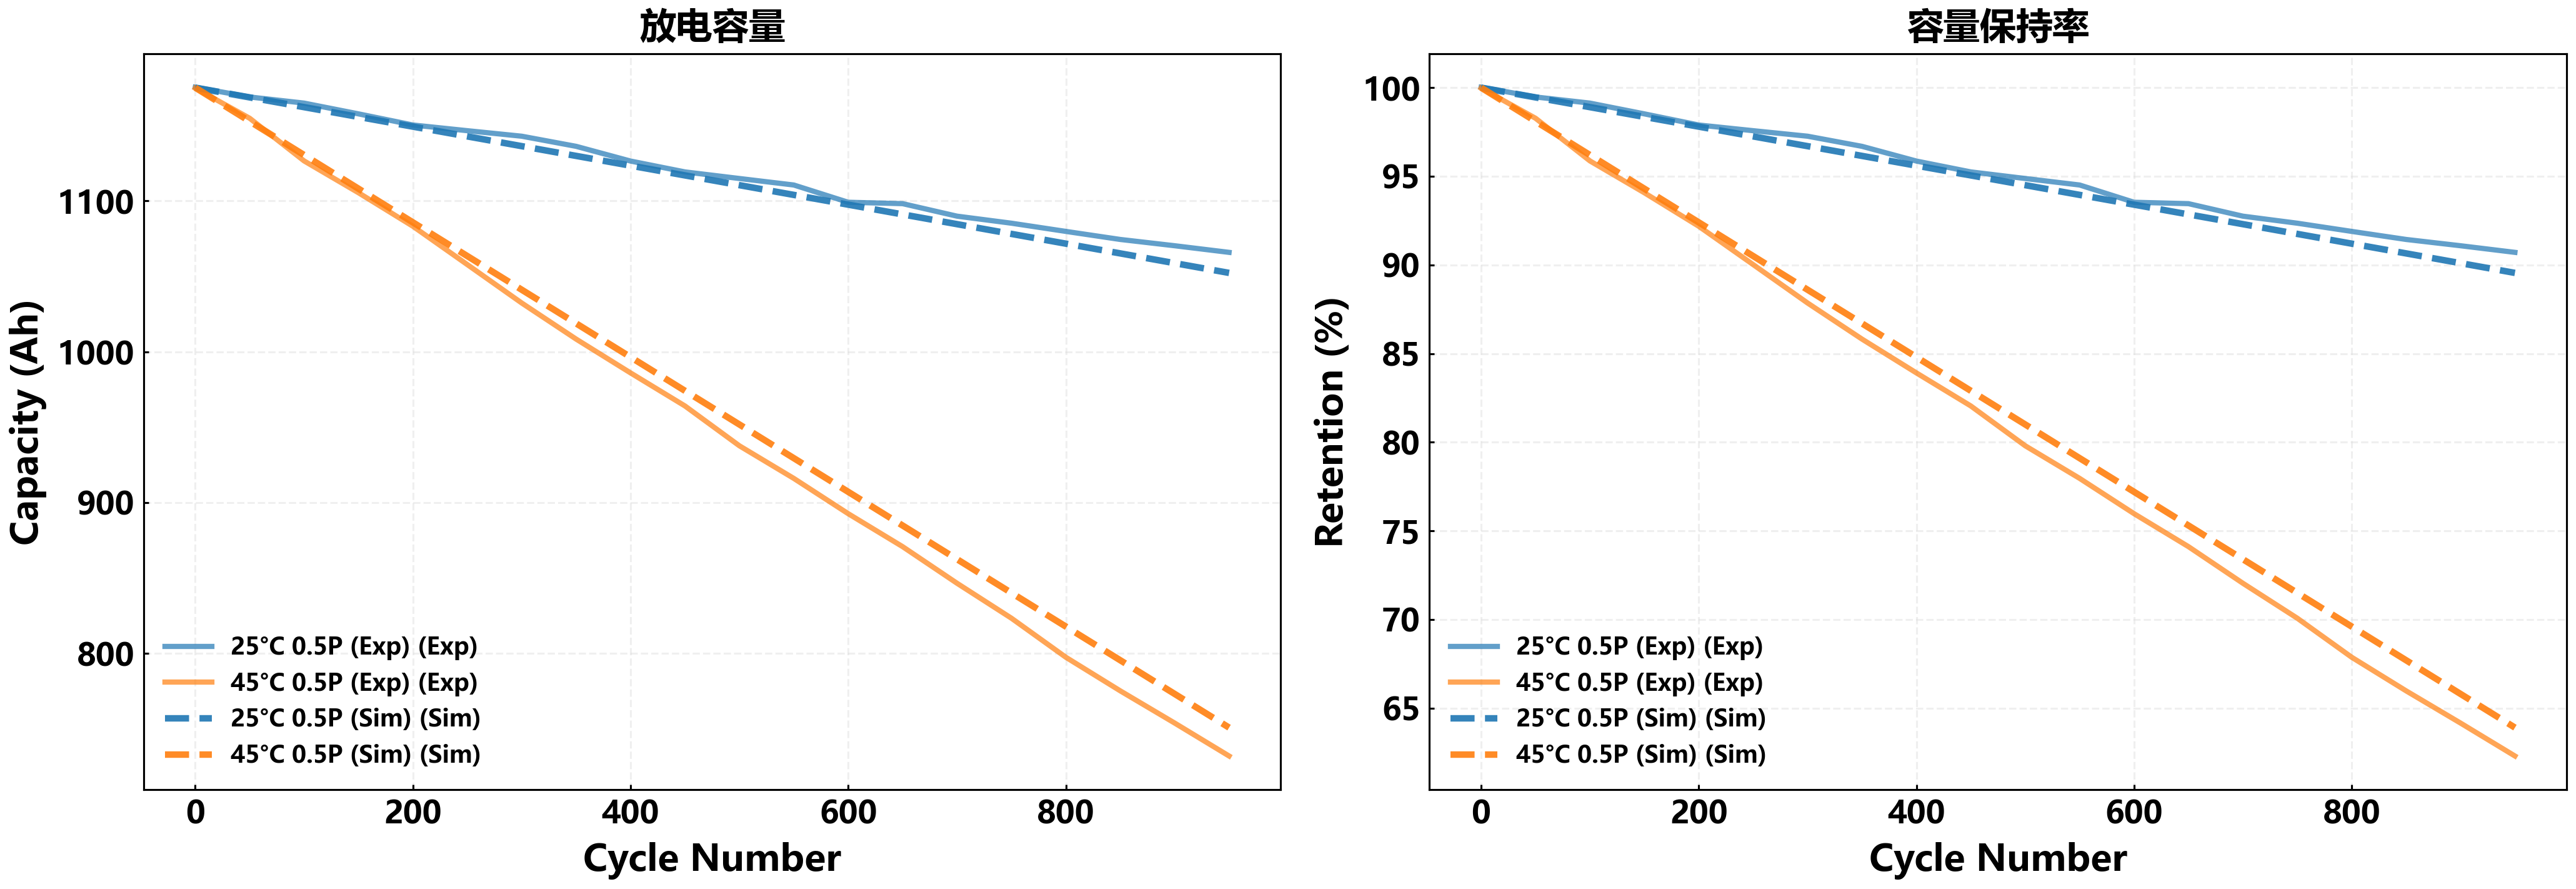

In [ ]:
rng = np.random.default_rng(0)

# 构造两组实验数据（25°C 0.5P / 45°C 0.5P）
cycle = np.arange(0, 1000, 50)
exp_25 = 1.0 - 1e-4 * cycle + rng.normal(0, 0.002, cycle.size)
exp_45 = 1.0 - 4e-4 * cycle + rng.normal(0, 0.002, cycle.size)

# 构造对应的仿真数据（更平滑，无噪声）
sim_25 = 1.0 - 1.1e-4 * cycle
sim_45 = 1.0 - 3.8e-4 * cycle

plotter = BatteryPlotter()
plotter.add_exp_data("25°C 0.5P (Exp)", cycle, capacity=exp_25 * 1175, retention=exp_25)
plotter.add_exp_data("45°C 0.5P (Exp)", cycle, capacity=exp_45 * 1175, retention=exp_45)
plotter.add_sim_data("25°C 0.5P (Sim)", cycle, capacity=sim_25 * 1175, retention=sim_25)
plotter.add_sim_data("45°C 0.5P (Sim)", cycle, capacity=sim_45 * 1175, retention=sim_45)

plotter.plot(target_exp="all", target_sim="all", ylabel_left="Capacity (Ah)")
plt.show()

## 2. 按关键词筛选要绘的曲线

`target_exp` 接受：`None`（不绘）/ `"all"`（全部）/ 字符串（子串匹配）/ tuple（多关键词 AND）/ list（直接当 key 列表用）。

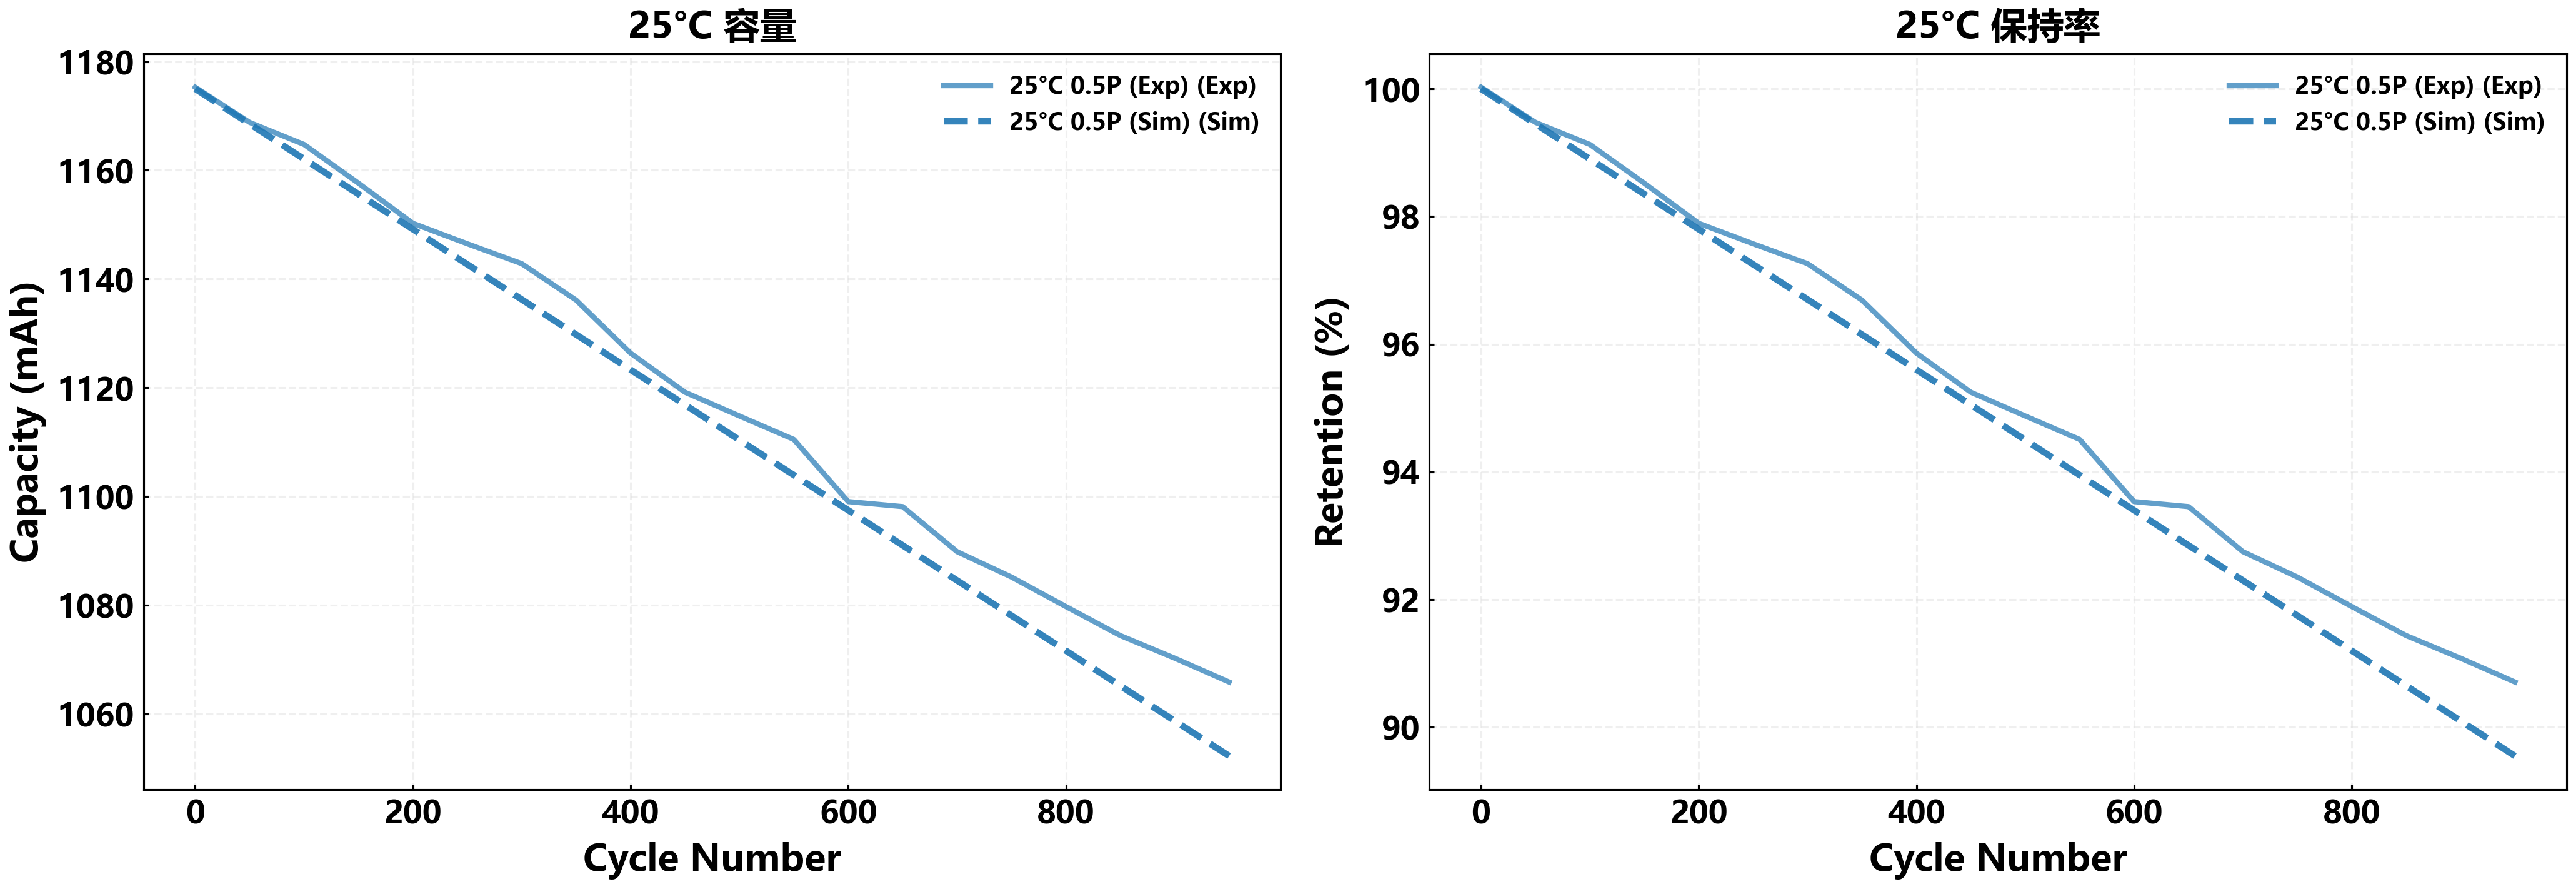

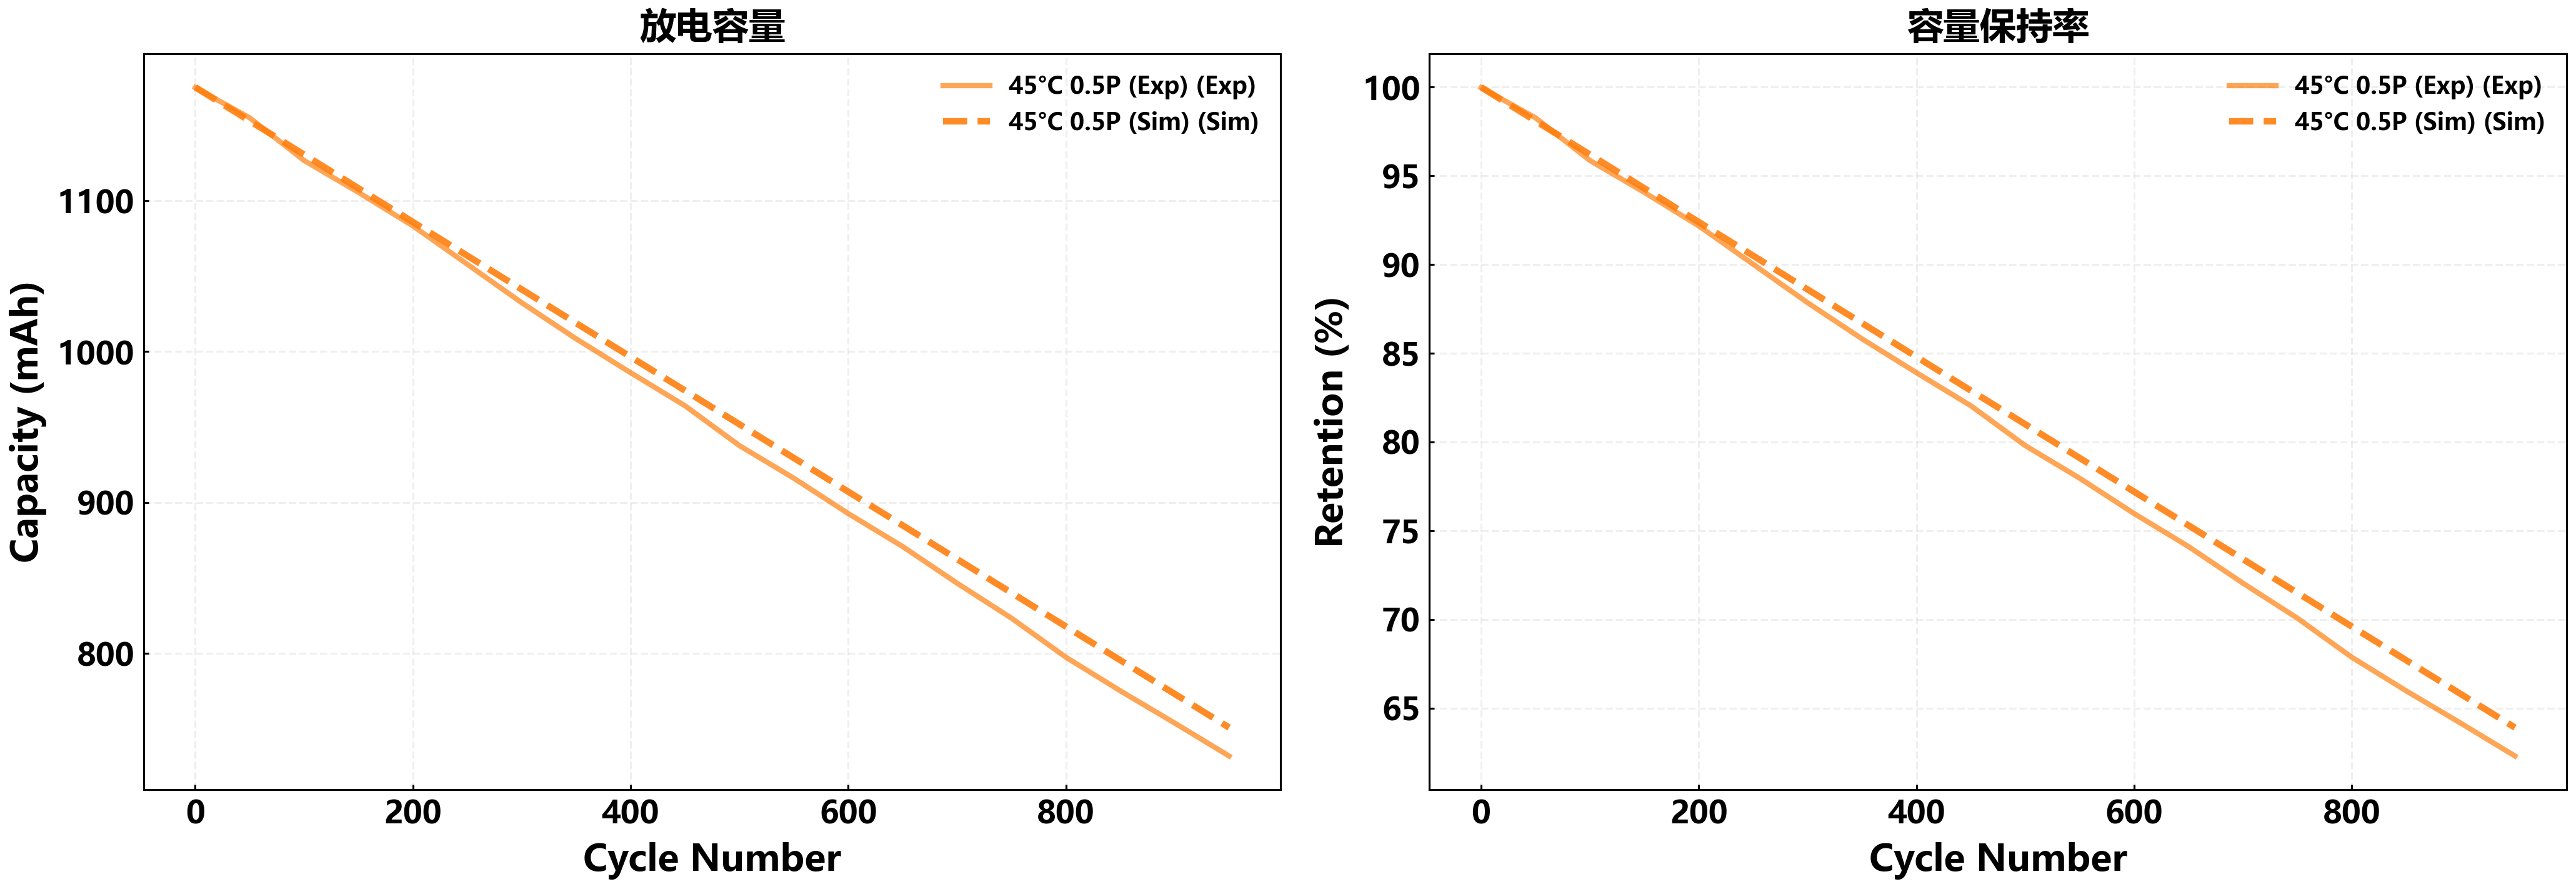

In [ ]:
# 只画 25°C 的实验 + 仿真
plotter.plot(target_exp="25°C", target_sim="25°C", title_left="25°C 容量", title_right="25°C 保持率")
plt.show()

# tuple = 多关键词 AND：必须同时包含 "45" 和 "0.5P"
plotter.plot(target_exp=("45", "0.5P"), target_sim=("45", "0.5P"))
plt.show()

## 3. 颜色按标签归一化共享

`BatteryPlotter` 用 `_get_normalized_key`（去掉 `(Sim)/(Exp)`、空格、`°`）把同一工况的
实验和仿真映射到同一颜色——`25°C 0.5P (Exp)` 与 `25°C 0.5P (Sim)` 会拿到同一种色。

下面打印颜色字典证实这一点：

In [ ]:
for k, c in plotter.color_map.items():
    print(f"{k:25s}  → RGBA={tuple(round(x, 3) for x in c)}")

## 4. 单位换算与基线偏移

`factor` 与 `bias` 在绘制时会作用在 **capacity 数据**上（`y' = y * factor + bias`）。
用于做单位换算（Ah → mAh）或基线对齐。

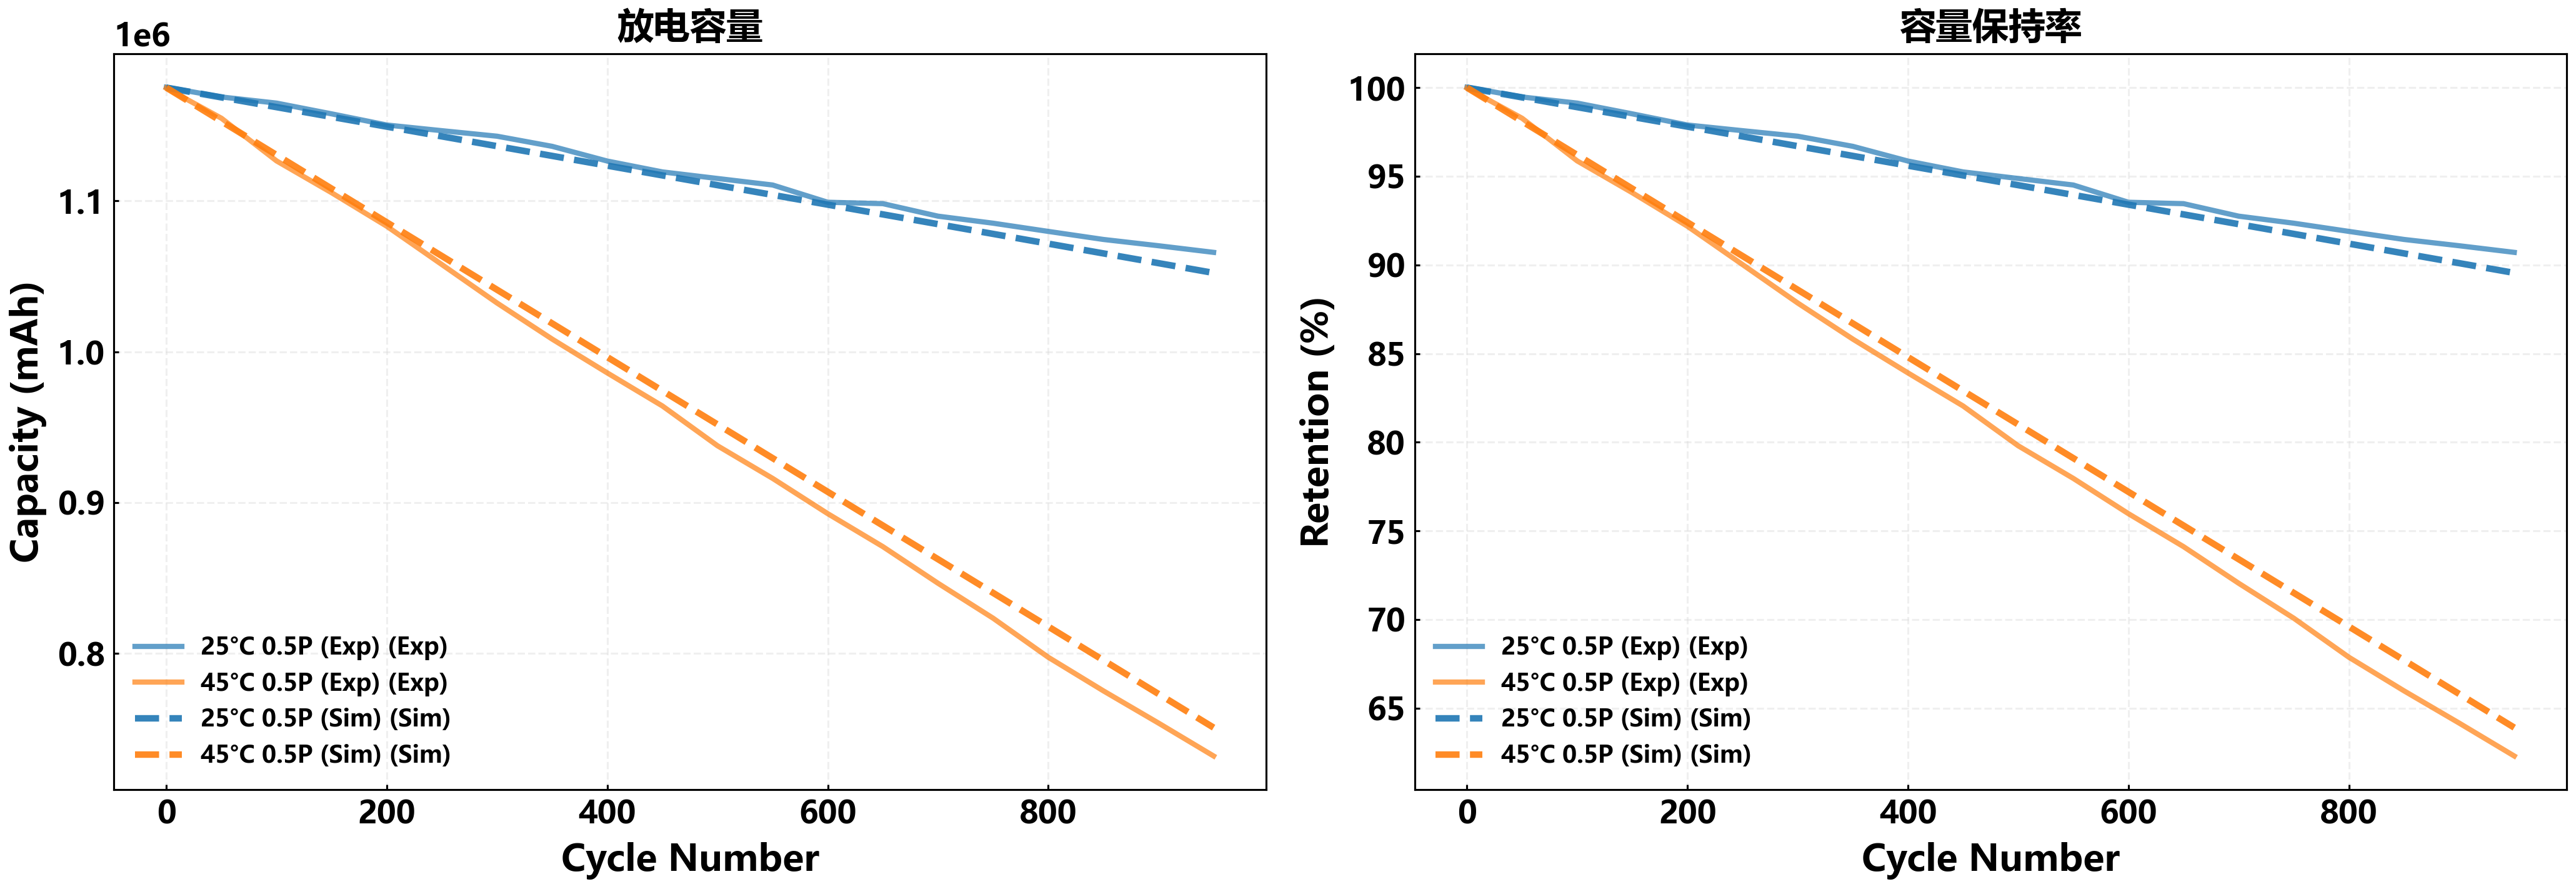

In [ ]:
# capacity 从 Ah 换算到 mAh：factor=1000
plotter.plot(
    target_exp="all", target_sim="all",
    factor=1000.0, ylabel_left="Capacity (mAh)",
)
plt.show()

## 5. 多温度多倍率的扫描示例

实际项目里常一次性扫 4–8 个工况，BatteryPlotter 的命名/筛选机制就是为这类场景设计的。

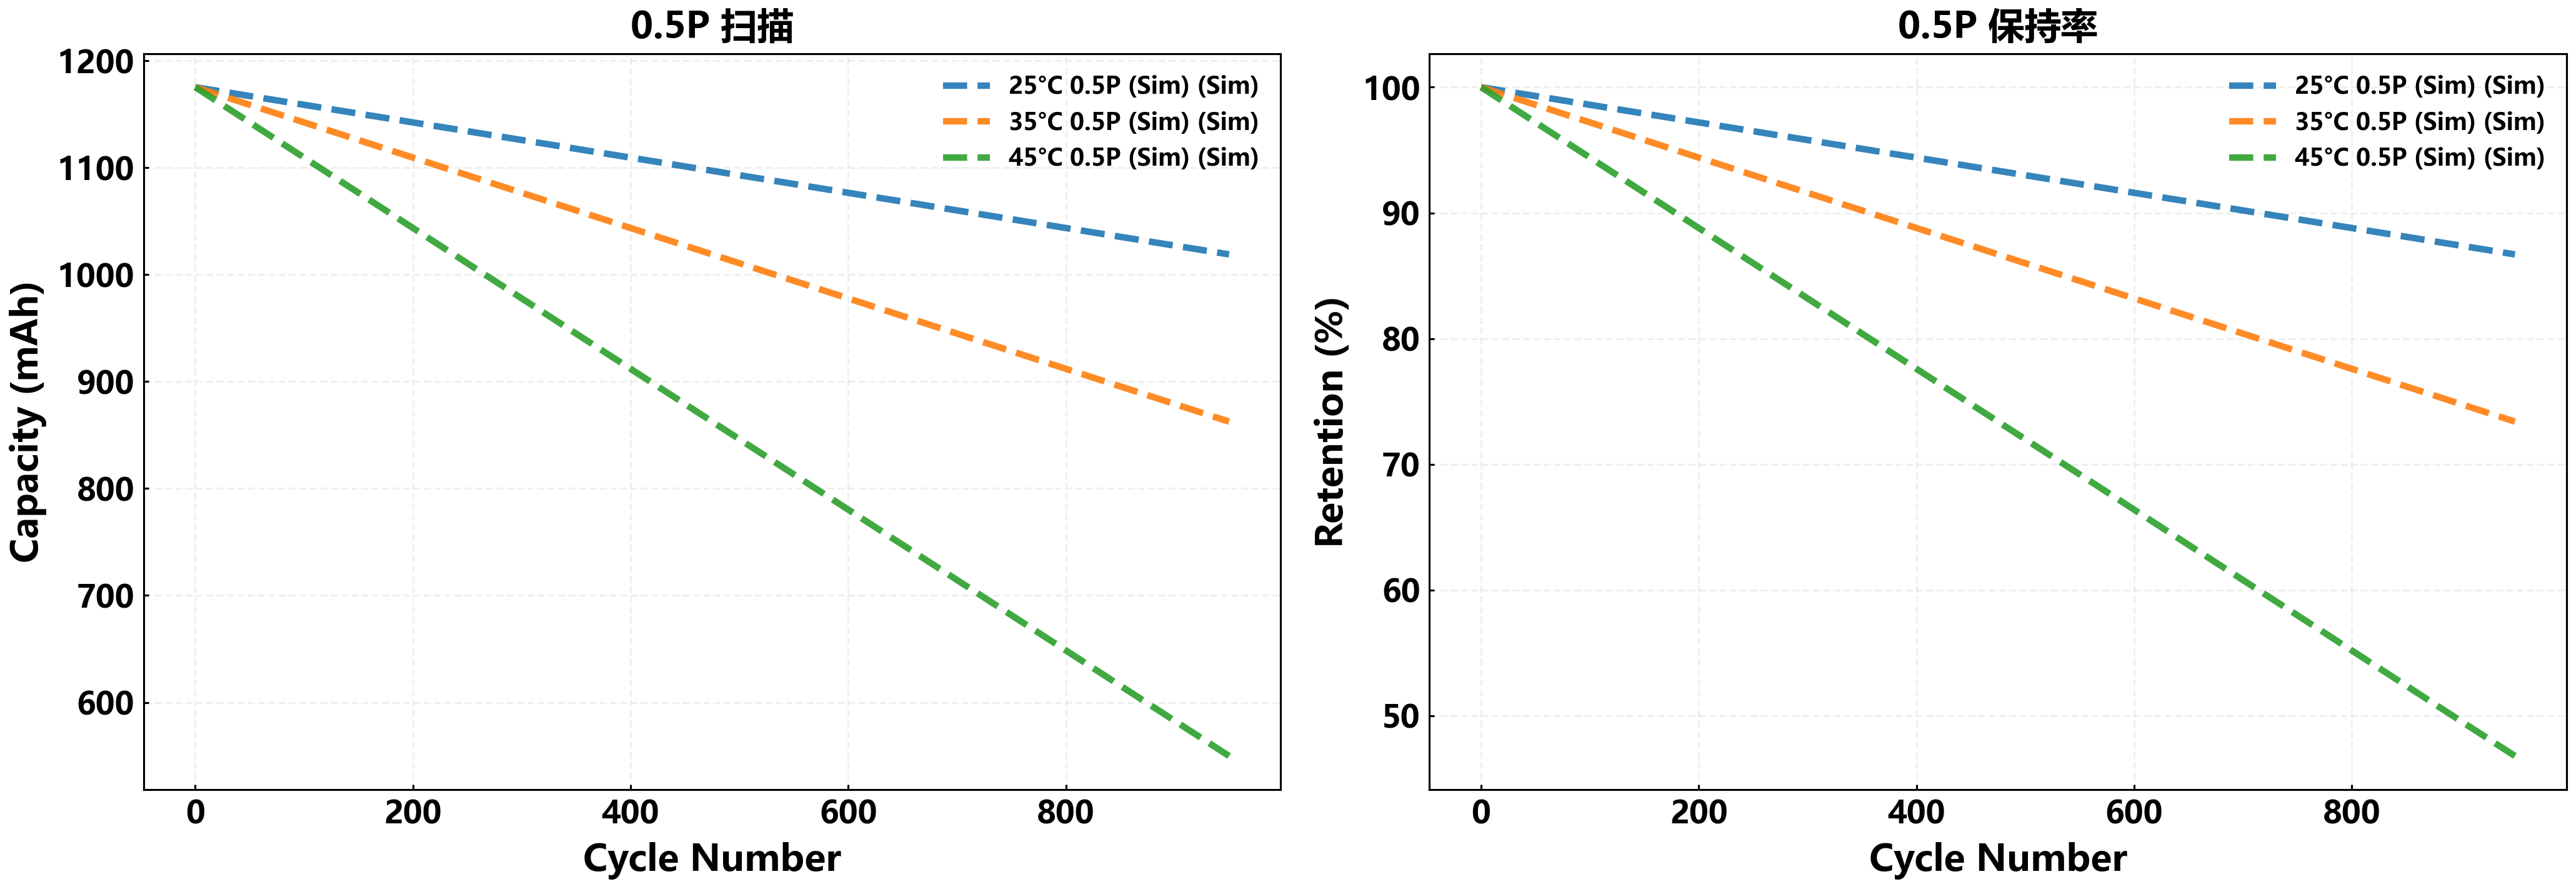

In [ ]:
plotter2 = BatteryPlotter()
for T_label, k_T in [("25°C", 1.0), ("35°C", 2.0), ("45°C", 4.0)]:
    for rate_label, k_rate in [("0.25P", 1.0), ("0.5P", 1.4)]:
        label = f"{T_label} {rate_label}"
        decay = 1.0 - 1e-4 * k_T * k_rate * cycle
        plotter2.add_sim_data(f"{label} (Sim)", cycle, capacity=decay * 1175, retention=decay)

# 一次性看所有 0.5P 工况
plotter2.plot(target_sim="0.5P", title_left="0.5P 扫描", title_right="0.5P 保持率")
plt.show()

## 6. 关于 `plot_swelling` / `plot_heat`（需要 sol_list）

这两个方法的入口需要 PyBaMM `Solution` 对象：

```python
# 概念示例（运行版见 analysis_demo.ipynb）
from src.plotting import plot_swelling, process_sol_list_for_all_heat_components

plot_swelling(sol_list, sim_labels=[...], params=params, k_stiffness=1e9, preload_force=300)
process_sol_list_for_all_heat_components(plotter, sol_list, labels)
plotter.plot_heat(target_sim="all")
```

## 注意

- `src` 模块内部**不**调用 `plt.show()`（见 [src/AGENTS.md](../src/AGENTS.md)）。
  notebook 用 `%matplotlib inline` 时可省略；非 inline 后端必须显式 `plt.show()`。
- `BatteryPlotter` 不会清空状态——同一个实例反复 `add_*_data` 会累加。